# **Clustering based Course Recommender System**


## Prepare and setup lab environment


In [1]:
%pip install scikit-learn
%pip install seaborn
%pip install pandas
%pip install matplotlib

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [3]:
# also set a random state
rs = 123

### Load the user profile dataset


In [4]:
# Importing the pandas library, which is commonly used for data manipulation and analysis
import pandas as pd

# Defining the URL of the CSV file containing user profiles
user_profile_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv"

# Using pandas' read_csv function to read the CSV file from the specified URL into a DataFrame
user_profile_df = pd.read_csv(user_profile_url)

# Displaying the first few rows of the DataFrame to inspect its contents
user_profile_df.head()


,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


In [5]:
user_profile_df.shape

(33901, 15)

In [6]:
feature_names = list(user_profile_df.columns[1:])
feature_names

['Database',
 'Python',
 'CloudComputing',
 'DataAnalysis',
 'Containers',
 'MachineLearning',
 'ComputerVision',
 'DataScience',
 'BigData',
 'Chatbot',
 'R',
 'BackendDev',
 'FrontendDev',
 'Blockchain']

In [7]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000
mean,1.064064e+06,5.518569,3.493791,2.307100,3.624701,0.998938,3.048022,0.001770,5.087343,4.750450,0.462995,1.017433,2.269461,0.315802,0.986844
std,4.972578e+05,7.611941,4.227254,3.841858,4.760135,2.351764,4.624004,0.072846,5.230697,7.216228,1.055186,2.342532,4.310752,1.363462,1.950585
min,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.813480e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.043907e+06,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.451159e+06,9.000000,6.000000,3.000000,6.000000,0.000000,3.000000,0.000000,9.000000,6.000000,0.000000,0.000000,3.000000,0.000000,2.000000
max,2.103039e+06,63.000000,18.000000,38.000000,48.000000,15.000000,39.000000,3.000000,32.000000,54.000000,6.000000,18.000000,54.000000,15.000000,12.000000


In [8]:
# Use StandardScaler to make each feature with mean 0, standard deviation 1
# Instantiating a StandardScaler object
scaler = StandardScaler()

# Standardizing the selected features (feature_names) in the user_profile_df DataFrame
user_profile_df[feature_names] = scaler.fit_transform(user_profile_df[feature_names])

# Printing the mean and standard deviation of the standardized features
print("mean {} and standard deviation{} ".format(user_profile_df[feature_names].mean(), user_profile_df[feature_names].std()))

mean Database          -3.353495e-17
Python            -5.700942e-17
CloudComputing    -3.521170e-17
DataAnalysis      -7.671120e-17
Containers         3.353495e-18
MachineLearning    3.688845e-17
ComputerVision    -1.509073e-17
DataScience       -1.676748e-17
BigData            6.706990e-17
Chatbot           -6.874665e-17
R                  4.233788e-17
BackendDev         1.383317e-17
FrontendDev        5.051202e-17
Blockchain        -5.281755e-17
dtype: float64 and standard deviationDatabase           1.000015
Python             1.000015
CloudComputing     1.000015
DataAnalysis       1.000015
Containers         1.000015
MachineLearning    1.000015
ComputerVision     1.000015
DataScience        1.000015
BigData            1.000015
Chatbot            1.000015
R                  1.000015
BackendDev         1.000015
FrontendDev        1.000015
Blockchain         1.000015
dtype: float64 


In [9]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04
mean,1.064064e+06,-3.353495e-17,-5.700942e-17,-3.521170e-17,-7.671120e-17,3.353495e-18,3.688845e-17,-1.509073e-17,-1.676748e-17,6.706990e-17,-6.874665e-17,4.233788e-17,1.383317e-17,5.051202e-17,-5.281755e-17
std,4.972578e+05,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,2.000000e+00,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
25%,6.813480e+05,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
50%,1.043907e+06,-3.308757e-01,-1.168130e-01,-6.005256e-01,-1.312380e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-3.990622e-01,-3.811535e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
75%,1.451159e+06,4.573712e-01,5.928781e-01,1.803581e-01,4.990056e-01,-4.247674e-01,-1.038556e-02,-2.429612e-02,7.480294e-01,1.731609e-01,-4.387873e-01,-4.343370e-01,1.694715e-01,-2.316212e-01,5.194189e-01
max,2.103039e+06,7.551593e+00,3.431642e+00,9.290667e+00,9.322416e+00,5.953517e+00,7.775190e+00,4.115884e+01,5.145214e+00,6.824934e+00,5.247500e+00,7.249771e+00,1.200053e+01,1.076995e+01,5.646161e+00


In [10]:
features = user_profile_df.loc[:, user_profile_df.columns != 'user']
features

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419
2,2.427988,1.066006,4.084776,4.280467,-0.424767,5.828796,-0.024296,3.233395,1.281790,1.456642,5.542191,5.505047,2.702132,2.570116
3,-0.462250,-0.826504,-0.600526,-0.341319,-0.424767,-0.659184,-0.024296,-0.972608,-0.381153,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
4,0.063248,-0.826504,-0.600526,0.078843,-0.424767,-0.659184,-0.024296,-0.972608,0.173161,-0.438787,0.419453,-0.526473,-0.231621,-0.505930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33896,-0.330876,-0.116813,0.180358,0.499006,-0.424767,-0.659184,-0.024296,0.174484,-0.658311,-0.438787,2.127032,0.865416,-0.231621,1.032093
33897,-0.724999,-0.826504,-0.079936,-0.761482,-0.424767,-0.659184,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
33898,-0.330876,0.592878,0.961242,-0.761482,-0.424767,2.368540,-0.024296,0.748029,-0.658311,-0.438787,0.846348,-0.526473,-0.231621,-0.505930
33899,-0.724999,-0.826504,-0.600526,-0.761482,-0.424767,-0.226652,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930


In [11]:
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']
user_ids

,user
0,2
1,4
2,5
3,7
4,8
...,...
33896,2102054
33897,2102356
33898,2102680
33899,2102983


### TASK: Perform K-means clustering algorithm on the user profile feature vectors


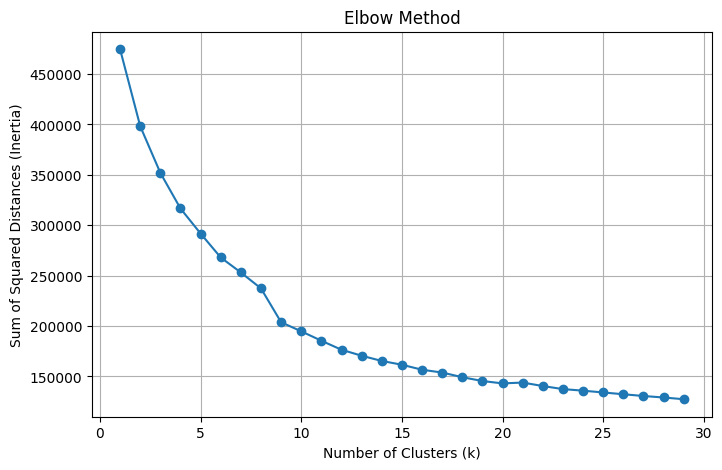

In [12]:
# Candidate values for k
list_k = list(range(1, 30))

# Store the sum of squared distances (inertia)
ssd = []

# Train KMeans for each k
for k in list_k:
    model = KMeans(n_clusters=k, random_state=rs)
    model.fit(features)
    ssd.append(model.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list_k, ssd, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Distances (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

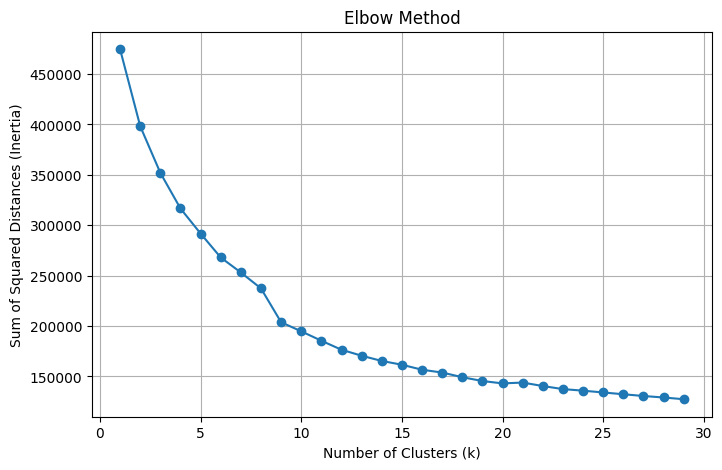

In [13]:
cluster_labels = [None] * len(user_ids)

TODO: Apply KMeans() on the features with optimized n_cluster parameter after model fitting, you can find output cluster labels in model.labels_ attribute

In [20]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=k, random_state=rs)
model.fit(features)

cluster_labels = model.labels_

In [21]:
def combine_cluster_labels(user_ids, labels):
    # Convert labels to a DataFrame
    labels_df = pd.DataFrame(labels)
    # Merge user_ids DataFrame with labels DataFrame based on index
    cluster_df = pd.merge(user_ids, labels_df, left_index=True, right_index=True)
    # Rename columns to 'user' and 'cluster'
    cluster_df.columns = ['user', 'cluster']
    return cluster_df

### TASK: Apply PCA on user profile feature vectors to reduce dimensions


In [22]:
# Extracting features from the user_profile_df DataFrame, excluding the 'user' column
features = user_profile_df.loc[:, user_profile_df.columns != 'user']

# Extracting user IDs from the user_profile_df DataFrame
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']

# Creating a list of feature names by excluding the 'user' column name
feature_names = list(user_profile_df.columns[1:])

In [23]:
print(f"There are {len(feature_names)} features for each user profile.")

There are 14 features for each user profile.


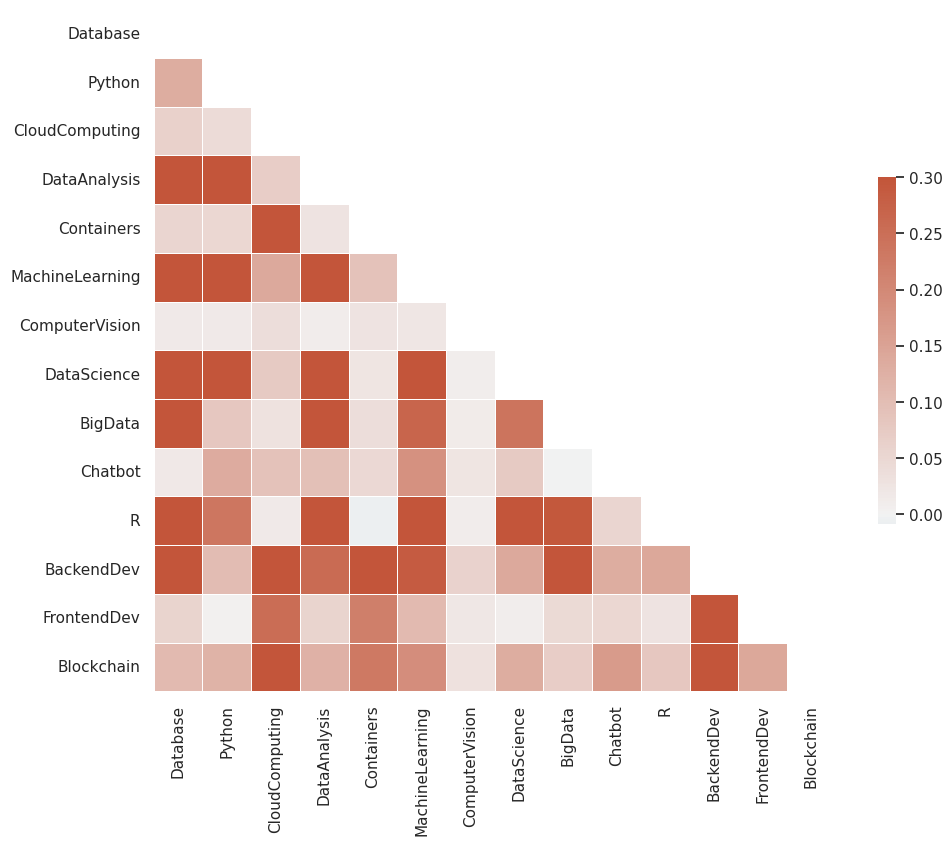

In [24]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = features.cov()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


plt.show()

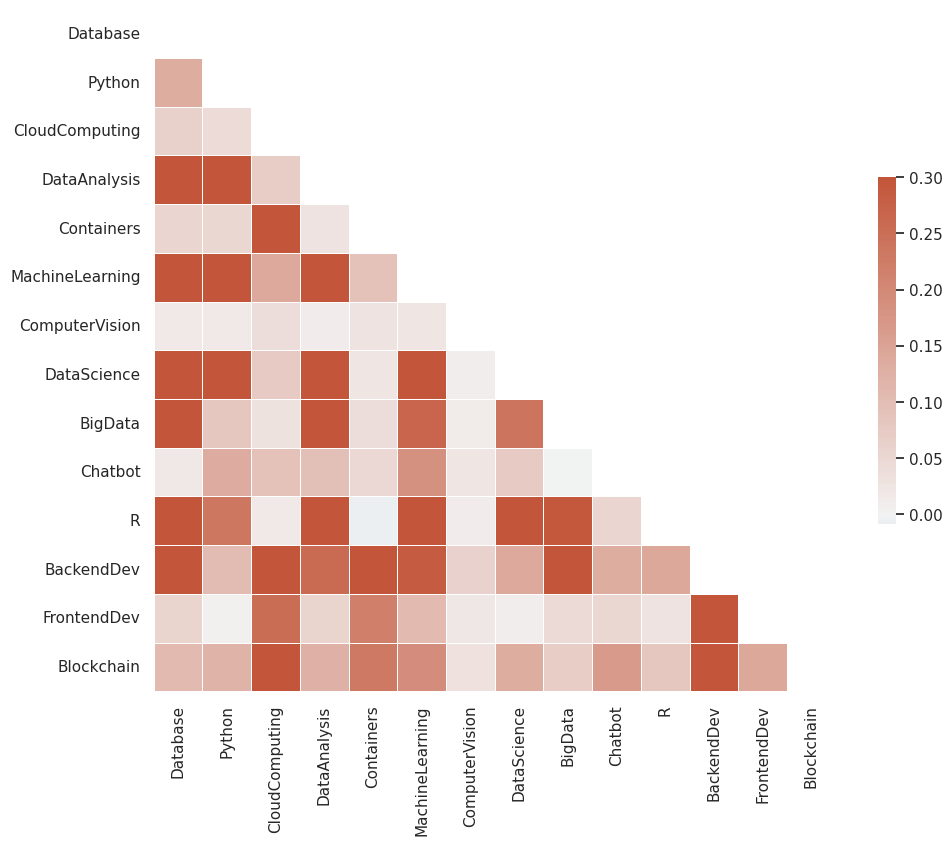

_TODO: Find the optimized `n_components` for PCA_


In [30]:
from sklearn.decomposition import PCA

# Try different numbers of components from 1 to 14
for n in range(1, 15):
    pca = PCA(n_components=n)
    pca.fit(features)

    explained_variance = sum(pca.explained_variance_ratio_)

    if explained_variance >= 0.90:
        print("Optimized n_components:", n)
        print("Explained variance ratio:", explained_variance)
        break

Optimized n_components: 9
Explained variance ratio: 0.927269559130768


_TODO: Perform PCA to transform original user profile features_

In [31]:
from sklearn.decomposition import PCA

# Find the minimum number of components that explain at least 90% variance
for n in range(1, 15):
    pca = PCA(n_components=n)
    pca.fit(features)

    explained_variance = sum(pca.explained_variance_ratio_)

    if explained_variance >= 0.90:
        break

print("Optimized n_components:", n)
print("Explained variance:", explained_variance)

# Apply PCA using the optimized number of components
pca = PCA(n_components=n)
features_pca = pca.fit_transform(features)

# Create column names for the PCA features
pca_columns = [f"PC{i}" for i in range(n)]

# Convert transformed features into a DataFrame
pca_df = pd.DataFrame(features_pca, columns=pca_columns)

# Add user IDs
pca_df.insert(0, "user", user_ids.values)

# Display the transformed dataframe
pca_df.head()

Optimized n_components: 9
Explained variance: 0.927269559130768


,user,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,2,17.772494,0.200681,1.730609,2.567359,-3.825814,-2.707154,0.681042,2.312613,0.868272
1,4,7.145199,-2.847481,2.358636,-0.576654,0.398803,0.134533,0.549769,0.469033,0.033405
2,5,11.363270,1.873619,-1.522077,1.076144,-1.711688,-0.883212,1.677582,2.937669,2.097639
3,7,-1.834033,-0.277462,0.564905,0.053470,-0.064440,-0.165757,0.030956,0.039519,0.210887
4,8,-1.049125,-0.684767,1.072765,0.006371,-0.005695,-0.118686,0.118559,0.559292,0.186379


### TASK: Perform k-means clustering on the PCA transformed feature vectors


In [32]:
from sklearn.cluster import KMeans

# Apply KMeans on PCA features
model = KMeans(n_clusters=k, random_state=rs)

# Fit the model
model.fit(features_pca)

# Get cluster labels
cluster_labels = model.labels_

# Combine user IDs and cluster labels
cluster_df = combine_cluster_labels(user_ids, cluster_labels)

cluster_df.head()

,user,cluster
0,2,22
1,4,11
2,5,27
3,7,3
4,8,2


### TASK: Generate course recommendations based on the popular courses in the same cluster


In [33]:
test_user_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"

# Reading the test user data CSV file into a pandas DataFrame
# Selecting only the 'user' and 'item' columns using indexing
test_users_df = pd.read_csv(test_user_url)[['user', 'item']]

# Displaying the first few rows of the DataFrame to inspect its contents
test_users_df.head()

,user,item
0,1889878,CC0101EN
1,1342067,CL0101EN
2,1990814,ML0120ENv3
3,380098,BD0211EN
4,779563,DS0101EN


In [34]:
test_users_labelled = pd.merge(test_users_df, cluster_df, left_on='user', right_on='user')

In [35]:
test_users_labelled.head()

,user,item,cluster
0,1889878,CC0101EN,27
1,1342067,CL0101EN,12
2,1990814,ML0120ENv3,27
3,380098,BD0211EN,27
4,779563,DS0101EN,24


In [36]:
# Extracting the 'item' and 'cluster' columns from the test_users_labelled DataFrame
courses_cluster = test_users_labelled[['item', 'cluster']]

# Adding a new column 'count' with a value of 1 for each row in the courses_cluster DataFrame
courses_cluster['count'] = [1] * len(courses_cluster)

# Grouping the DataFrame by 'cluster' and 'item', aggregating the 'count' column with the sum function,
# and resetting the index to make the result more readable
courses_cluster_grouped = courses_cluster.groupby(['cluster','item']).agg(enrollments=('count','sum')).reset_index()

_TODO: For each test user, try to recommend any unseen courses based on the popular courses in his/her cluster. You may use an enrollment count threshold (such as larger than 10) to determine if it is a popular course in the cluster_


In [37]:
# Create a list to store recommendations
recommendations = []

# Go through each test user
for _, user_row in test_users_labelled.iterrows():

    user = user_row['user']
    cluster = user_row['cluster']

    # Get courses in the user's cluster with more than 10 enrollments
    popular_courses = courses_cluster_grouped[
        (courses_cluster_grouped['cluster'] == cluster) &
        (courses_cluster_grouped['enrollments'] > 10)
    ]

    # Get courses the user has already enrolled in
    user_courses = test_users_df[
        test_users_df['user'] == user
    ]['item'].tolist()

    # Find popular courses that the user has not taken
    unseen_courses = popular_courses[
        ~popular_courses['item'].isin(user_courses)
    ]

    # Add recommendations
    for item in unseen_courses['item']:
        recommendations.append({
            'user': user,
            'item': item,
            'cluster': cluster
        })

# Convert recommendations to a DataFrame
recommendations_df = pd.DataFrame(recommendations)

# Display the recommendations
recommendations_df.head()

,user,item,cluster
0,1889878,BD0111EN,27
1,1889878,BD0115EN,27
2,1889878,BD0121EN,27
3,1889878,BD0123EN,27
4,1889878,BD0131EN,27


On average, how many new/unseen courses have been recommended to each user?

In [38]:
# Count recommended courses for each user
recommendation_counts = recommendations_df.groupby('user').size()

# Include users who received zero recommendations
all_users = test_users_labelled['user'].unique()

recommendation_counts = recommendation_counts.reindex(
    all_users, fill_value=0
)

# Calculate the average
average_recommendations = recommendation_counts.mean()

print("Average number of new/unseen courses recommended per user:",
      average_recommendations)

Average number of new/unseen courses recommended per user: 341.32376626058226


What are the most frequently recommended courses? Return the top-10 commonly recommended courses across all users.

In [39]:
# Count how many times each course was recommended
course_recommendation_counts = recommendations_df['item'].value_counts()

# Get the top 10 most frequently recommended courses
top_10_courses = course_recommendation_counts.head(10)

print("Top 10 most frequently recommended courses:")
print(top_10_courses)

Top 10 most frequently recommended courses:
item
TA0105EN      204702
DB0151EN      204385
WA0101EN      203248
CL0101EN      202419
CC0103EN      197897
CC0201EN      193736
DW0101EN      192130
SC0105EN      190395
ML0120ENv2    189937
BD0123EN      189042
Name: count, dtype: int64
